# Lab 1 - Projectile Motion Solver

**Student:** Zaki Daouk  
**Date:** 2026-08-30

# Lab 1: Projectile Motion Simulation

This lab uses the Euler method to simulate projectile motion with and without air resistance. It also examines how extreme parameter values affect the accuracy of the simulation.

Newton's second law, $F = ma$, provides an update rule for advancing the state by one small time step. Repeating this update creates a numerical simulation.

A state vector packages position and velocity into one object:

$$
S = [x, y, v_x, v_y]
$$

Because Newton's laws require both position and velocity as initial conditions, the state vector supplies the two required pieces of information for each spatial dimension.

In [75]:
import numpy as np

# State: [x, y, vx, vy]
state = np.array([0.0, 0.0, 10.0, 20.0])  # launched from origin

## Part A - One-Dimensional Free Fall

A ball is dropped from rest at height $h = 100\ \mathrm{m}$ and falls under uniform gravity without air resistance.

Numerical landing time: 4.600 s
Exact landing time:     4.515 s
Time percentage error:  1.88%
Numerical final velocity: -45.126 m/s
Exact final velocity:     -44.294 m/s
Velocity percentage error: 1.88%


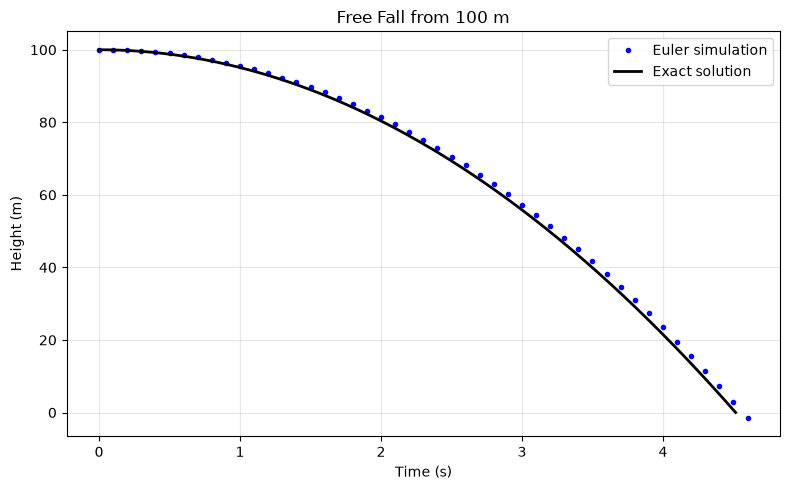

dt = 1.00 s | landing-time error = 32.88%
dt = 0.10 s | landing-time error = 1.88%
dt = 0.01 s | landing-time error = 0.33%


In [111]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_freefall(h, dt, g=9.81):
    """Simulate one-dimensional free fall with Euler's method."""
    y, vy, t = h, 0.0, 0.0
    t_arr, y_arr, vy_arr = [t], [y], [vy]

    while y >= 0:
        ay = -g
        y = y + vy * dt
        vy = vy + ay * dt
        t = t + dt
        t_arr.append(t)
        y_arr.append(y)
        vy_arr.append(vy)

    return np.array(t_arr), np.array(y_arr), np.array(vy_arr)


# Run the simulation from h = 100 m using the required dt = 0.1 s.
h = 100.0
dt = 0.1
g = 9.81
t_arr, y_arr, vy_arr = simulate_freefall(h, dt, g)

# Exact solution for comparison.
t_exact = np.linspace(0, np.sqrt(2 * h / g), 300)
y_exact = h - 0.5 * g * t_exact**2
t_land_exact = np.sqrt(2 * h / g)
vy_land_exact = -g * t_land_exact

final_time = t_arr[-1]
final_velocity = vy_arr[-1]
time_error_percent = abs(final_time - t_land_exact) / t_land_exact * 100
velocity_error_percent = abs(final_velocity - vy_land_exact) / abs(vy_land_exact) * 100

print(f"Numerical landing time: {final_time:.3f} s")
print(f"Exact landing time:     {t_land_exact:.3f} s")
print(f"Time percentage error:  {time_error_percent:.2f}%")
print(f"Numerical final velocity: {final_velocity:.3f} m/s")
print(f"Exact final velocity:     {vy_land_exact:.3f} m/s")
print(f"Velocity percentage error: {velocity_error_percent:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(t_arr, y_arr, 'bo', markersize=3, label='Euler simulation')
plt.plot(t_exact, y_exact, 'k-', linewidth=2, label='Exact solution')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Free Fall from 100 m')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Required timestep comparison.
for dt_test in [1.0, 0.1, 0.01]:
    t_test, _, _ = simulate_freefall(h, dt_test, g)
    error = abs(t_test[-1] - t_land_exact) / t_land_exact * 100
    print(f"dt = {dt_test:.2f} s | landing-time error = {error:.2f}%")

### Timestep accuracy

The timestep comparison shows that the numerical error decreases as $\Delta t$ becomes smaller. For example, the landing-time error is much larger at $\Delta t = 1.0\ \mathrm{s}$ than at $\Delta t = 0.01\ \mathrm{s}$. A smaller timestep uses more updates and gives a more accurate result. The effect of a large timestep on the shape of a projectile trajectory is demonstrated in Part B.

## Part B - Two-Dimensional Projectile

This section models a projectile launched from flat ground without air resistance, using $a_x = 0$ and $a_y = -g$.

Range:       92.065 m | exact: 91.743 m | error: 0.35%
Max height:  23.042 m | exact: 22.936 m | error: 0.46%
Flight time: 4.340 s | exact: 4.325 s | error: 0.35%


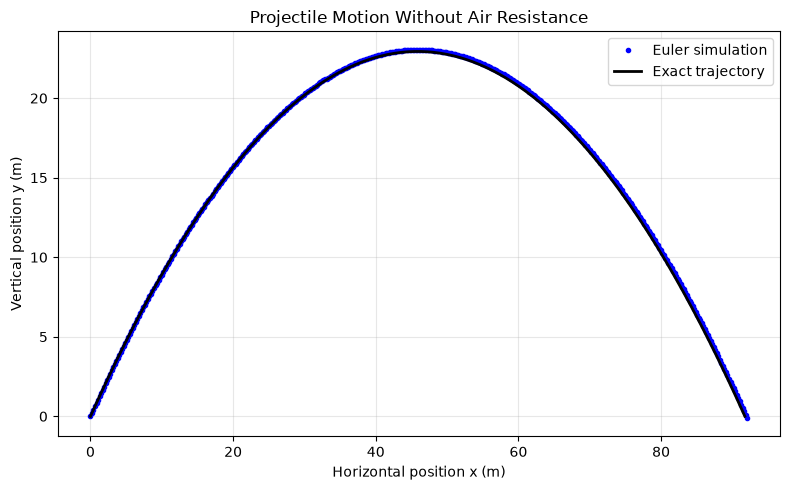

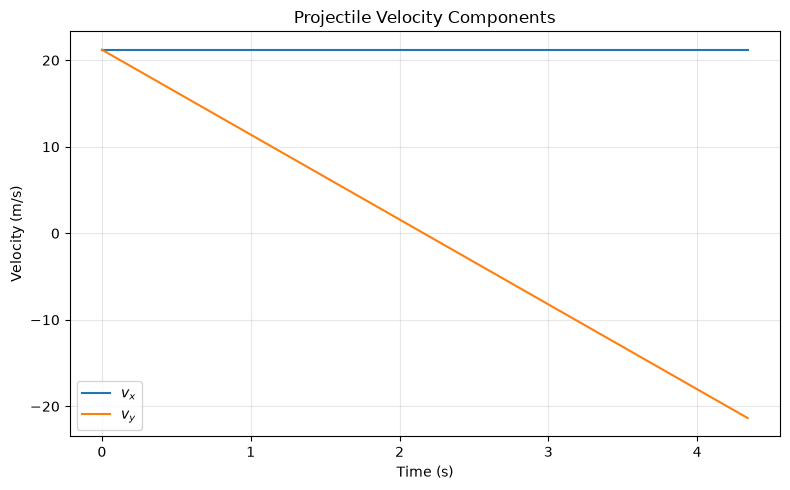

Maximum numerical range occurs at 45 degrees.


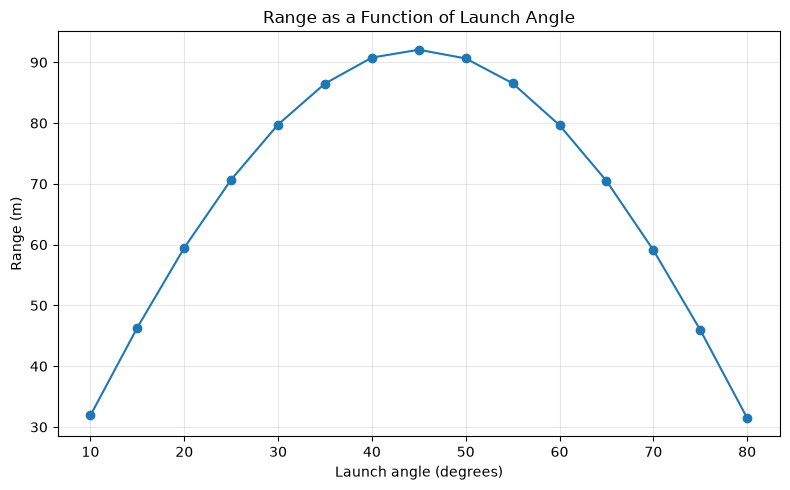

In [112]:
def simulate_projectile_2d(v0, theta_deg, dt, g=9.81):
    """Simulate a projectile launched from flat ground without drag."""
    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    t = 0.0

    t_arr, x_arr, y_arr = [t], [x], [y]
    vx_arr, vy_arr = [vx], [vy]

    while t == 0.0 or y >= 0.0:
        ax, ay = 0.0, -g
        x = x + vx * dt
        y = y + vy * dt
        vx = vx + ax * dt
        vy = vy + ay * dt
        t = t + dt

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)

    return (np.array(t_arr), np.array(x_arr), np.array(y_arr),
            np.array(vx_arr), np.array(vy_arr))


# Run the required case.
v0_projectile = 30.0
theta_deg_projectile = 45.0
dt_projectile = 0.01
t_projectile, x_projectile, y_projectile, vx_projectile, vy_projectile = simulate_projectile_2d(
    v0_projectile, theta_deg_projectile, dt_projectile
)

# Exact results for flat ground.
theta_projectile_rad = np.radians(theta_deg_projectile)
flight_time_exact = 2 * v0_projectile * np.sin(theta_projectile_rad) / 9.81
range_exact = v0_projectile**2 * np.sin(2 * theta_projectile_rad) / 9.81
max_height_exact = (v0_projectile * np.sin(theta_projectile_rad))**2 / (2 * 9.81)

numerical_range = x_projectile[-1]
numerical_height = np.max(y_projectile)
numerical_time = t_projectile[-1]
print(f"Range:       {numerical_range:.3f} m | exact: {range_exact:.3f} m | error: {abs(numerical_range - range_exact) / range_exact * 100:.2f}%")
print(f"Max height:  {numerical_height:.3f} m | exact: {max_height_exact:.3f} m | error: {abs(numerical_height - max_height_exact) / max_height_exact * 100:.2f}%")
print(f"Flight time: {numerical_time:.3f} s | exact: {flight_time_exact:.3f} s | error: {abs(numerical_time - flight_time_exact) / flight_time_exact * 100:.2f}%")

# Plot 1: numerical trajectory and exact parabola.
t_exact_plot = np.linspace(0, flight_time_exact, 300)
x_exact_plot = v0_projectile * np.cos(theta_projectile_rad) * t_exact_plot
y_exact_plot = (v0_projectile * np.sin(theta_projectile_rad) * t_exact_plot
               - 0.5 * 9.81 * t_exact_plot**2)
plt.figure(figsize=(8, 5))
plt.plot(x_projectile, y_projectile, 'bo', markersize=3, label='Euler simulation')
plt.plot(x_exact_plot, y_exact_plot, 'k-', linewidth=2, label='Exact trajectory')
plt.xlabel('Horizontal position x (m)')
plt.ylabel('Vertical position y (m)')
plt.title('Projectile Motion Without Air Resistance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: velocity components.
plt.figure(figsize=(8, 5))
plt.plot(t_projectile, vx_projectile, label='$v_x$')
plt.plot(t_projectile, vy_projectile, label='$v_y$')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Projectile Velocity Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Angle sweep.
angles = np.arange(10, 81, 5)
ranges = []
for sweep_angle in angles:
    _, x_sweep, _, _, _ = simulate_projectile_2d(v0_projectile, sweep_angle, dt_projectile)
    ranges.append(x_sweep[-1])

best_angle = angles[np.argmax(ranges)]
print(f"Maximum numerical range occurs at {best_angle} degrees.")
plt.figure(figsize=(8, 5))
plt.plot(angles, ranges, 'o-')
plt.xlabel('Launch angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range as a Function of Launch Angle')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part B observations

The horizontal velocity $v_x$ remains constant because there is no horizontal force, so $a_x = 0$. The vertical velocity $v_y$ decreases linearly because gravity provides the constant acceleration $a_y = -g$. The numerical results should closely match the exact range, maximum height, and flight time when $\Delta t$ is small. The angle sweep peaks near $45^\circ$, as predicted for level ground without air resistance.

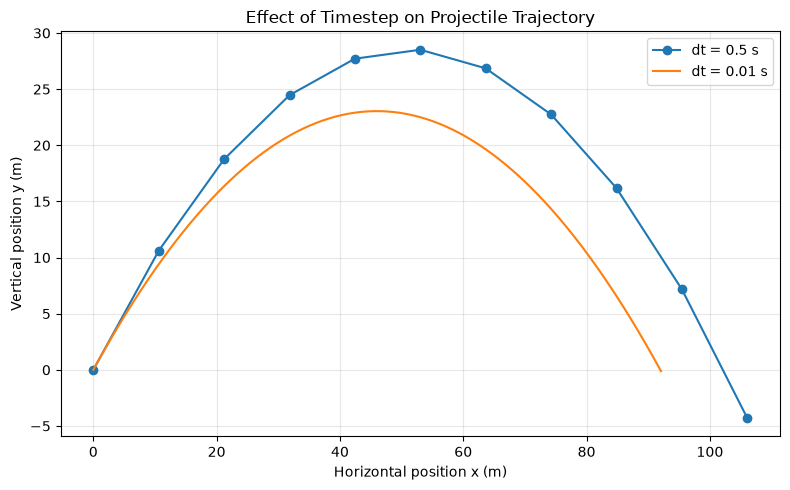

In [114]:
# Effect of a larger timestep
_, x_coarse, y_coarse, _, _ = simulate_projectile_2d(
    v0_projectile, theta_deg_projectile, dt=0.5
)
plt.figure(figsize=(8, 5))
plt.plot(x_coarse, y_coarse, 'o-', label='dt = 0.5 s')
plt.plot(x_projectile, y_projectile, '-', label='dt = 0.01 s')
plt.xlabel('Horizontal position x (m)')
plt.ylabel('Vertical position y (m)')
plt.title('Effect of Timestep on Projectile Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part C - Projectile With Air Resistance

This simulation models a baseball with quadratic air resistance. The baseball starts at ground level with $v_0 = 45\ \mathrm{m/s}$ and $\theta = 40^\circ$. The drag parameter is $b/m = 0.0046\ \mathrm{m^{-1}}$, and the Euler timestep is $\Delta t = 0.01\ \mathrm{s}$.

For the state vector $S = [x, y, v_x, v_y]$, the speed is $|\mathbf{v}| = \sqrt{v_x^2 + v_y^2}$. The acceleration components are

$$
a_x = -\frac{b}{m}|\mathbf{v}|v_x, \qquad a_y = -g - \frac{b}{m}|\mathbf{v}|v_y.
$$

The drag force opposes the velocity and is largest when the baseball is moving fastest. Unlike the no-drag case, this nonlinear model has no simple closed-form trajectory, so numerical simulation is especially useful.

Range without drag: 203.73 m
Range with drag:    125.00 m
Maximum height without drag: 42.79 m
Maximum height with drag:    32.22 m
Drag reduces range by: 38.6%


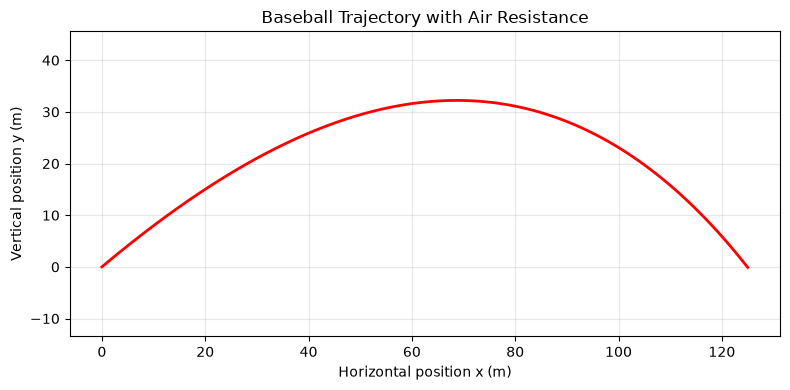

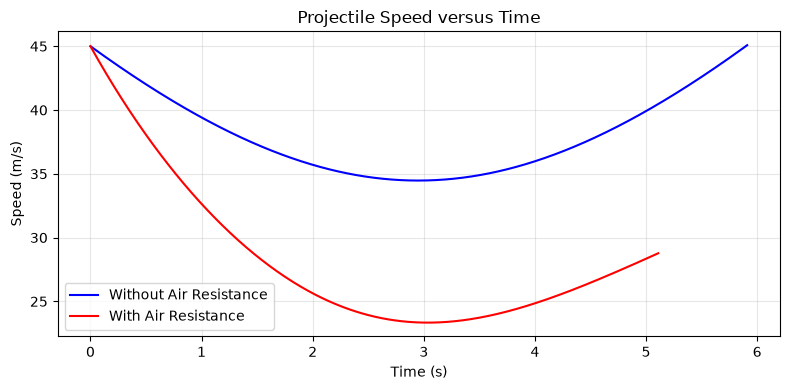

Optimal angle without drag: 45 degrees
Optimal angle with drag:    40 degrees


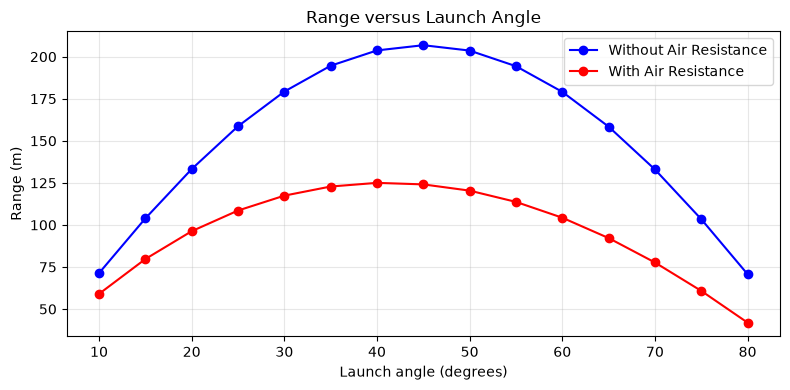

In [115]:
def simulate_projectile_drag(v0, theta_deg, dt, g=9.81, b_over_m=0.0046):
    """Simulate a projectile with quadratic air resistance."""
    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    t = 0.0

    t_arr, x_arr, y_arr = [t], [x], [y]
    vx_arr, vy_arr = [vx], [vy]

    while t == 0.0 or y >= 0.0:
        speed = np.sqrt(vx**2 + vy**2)
        ax = -b_over_m * speed * vx
        ay = -g - b_over_m * speed * vy

        x = x + vx * dt
        y = y + vy * dt
        vx = vx + ax * dt
        vy = vy + ay * dt
        t = t + dt

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)

    return (np.array(t_arr), np.array(x_arr), np.array(y_arr),
            np.array(vx_arr), np.array(vy_arr))


# Baseball parameters.
v0_baseball = 45.0
theta_deg_baseball = 40.0
b_over_m = 0.0046
dt_baseball = 0.01

# Run both cases with identical initial conditions.
t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_projectile_drag(
    v0_baseball, theta_deg_baseball, dt_baseball, b_over_m=b_over_m
)
t_nodrag, x_nodrag, y_nodrag, vx_nodrag, vy_nodrag = simulate_projectile_2d(
    v0_baseball, theta_deg_baseball, dt_baseball
)

# Keep names for the comparison plot below.
xs_drag, ys_drag = x_drag, y_drag
xs_projectile, ys_projectile = x_nodrag, y_nodrag

range_drag = x_drag[-1]
height_drag = np.max(y_drag)
range_nodrag = x_nodrag[-1]
height_nodrag = np.max(y_nodrag)
range_reduction = (1 - range_drag / range_nodrag) * 100
print(f"Range without drag: {range_nodrag:.2f} m")
print(f"Range with drag:    {range_drag:.2f} m")
print(f"Maximum height without drag: {height_nodrag:.2f} m")
print(f"Maximum height with drag:    {height_drag:.2f} m")
print(f"Drag reduces range by: {range_reduction:.1f}%")

# Plot the drag trajectory.
plt.figure(figsize=(8, 4))
plt.plot(x_drag, y_drag, 'r-', linewidth=2)
plt.xlabel('Horizontal position x (m)')
plt.ylabel('Vertical position y (m)')
plt.title('Baseball Trajectory with Air Resistance')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Speed versus time for both cases.
speed_drag = np.sqrt(vx_drag**2 + vy_drag**2)
speed_nodrag = np.sqrt(vx_nodrag**2 + vy_nodrag**2)
plt.figure(figsize=(8, 4))
plt.plot(t_nodrag, speed_nodrag, 'b-', label='Without Air Resistance')
plt.plot(t_drag, speed_drag, 'r-', label='With Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Projectile Speed versus Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Angle sweep with and without drag.
angles = np.arange(10, 81, 5)
ranges_nodrag_drag_sweep = []
ranges_drag_sweep = []
for sweep_angle in angles:
    _, x_nd, _, _, _ = simulate_projectile_2d(
        v0_baseball, sweep_angle, dt_baseball
    )
    _, x_wd, _, _, _ = simulate_projectile_drag(
        v0_baseball, sweep_angle, dt_baseball, b_over_m=b_over_m
    )
    ranges_nodrag_drag_sweep.append(x_nd[-1])
    ranges_drag_sweep.append(x_wd[-1])

best_angle_drag = angles[np.argmax(ranges_drag_sweep)]
print(f"Optimal angle without drag: {angles[np.argmax(ranges_nodrag_drag_sweep)]} degrees")
print(f"Optimal angle with drag:    {best_angle_drag} degrees")

plt.figure(figsize=(8, 4))
plt.plot(angles, ranges_nodrag_drag_sweep, 'b-o', label='Without Air Resistance')
plt.plot(angles, ranges_drag_sweep, 'r-o', label='With Air Resistance')
plt.xlabel('Launch angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range versus Launch Angle')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparing the trajectories

The next plot compares the baseball's trajectory with and without quadratic air resistance. Both simulations use the same initial speed of $45\ \mathrm{m/s}$, launch angle of $40^\circ$, and time step of $0.01\ \mathrm{s}$. The drag force opposes the velocity, so the baseball reaches a lower maximum height and travels a shorter horizontal distance.

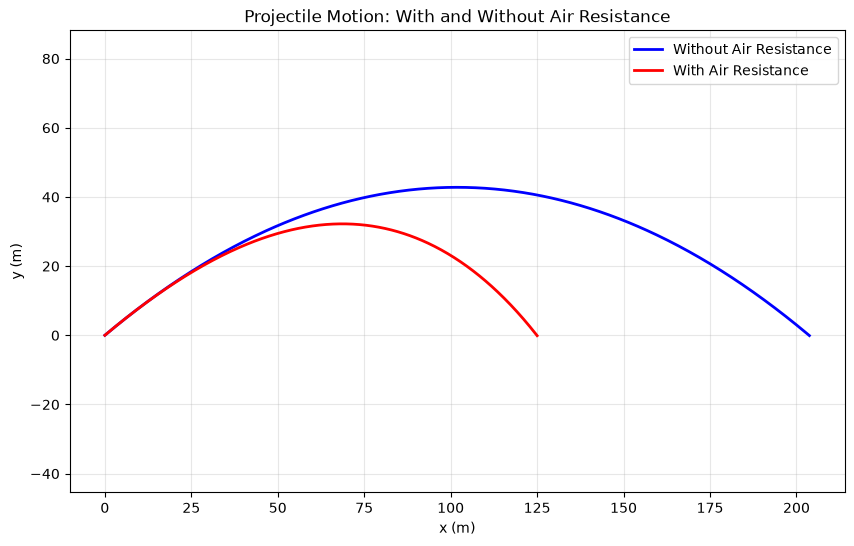

In [116]:
# Compare trajectories with and without air resistance
plt.figure(figsize=(10, 6))
plt.plot(xs_projectile, ys_projectile, 'b-', linewidth=2,
         label='Without Air Resistance')
plt.plot(xs_drag, ys_drag, 'r-', linewidth=2,
         label='With Air Resistance')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Motion: With and Without Air Resistance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

### Part C observations and answers

The no-drag projectile travels farther because no mechanical energy is removed from the motion. With quadratic drag, the force is strongest early in the flight when the speed is largest. It reduces the horizontal velocity throughout the trajectory and also reduces the upward motion, producing a lower and shorter path.

The drag angle sweep reaches its maximum near $40^\circ$, below the no-drag optimum of $45^\circ$. A lower angle gives the baseball more horizontal velocity and reduces the time available for drag to slow it down. The exact optimum depends on the speed, drag parameter, and timestep.

To check whether Euler's method is reliable,I repeated the simulation with smaller values of $\Delta t$ and compare the range, maximum height, and landing time. The results converge as $\Delta t$ decreases.

### Euler method and convergence

Euler's method is first-order accurate: reducing $\Delta t$ should reduce the global error approximately in proportion to $\Delta t$. The convergence test below uses the known free-fall solution to measure this error. Notice that updating position with the old velocity is standard Euler; using the newly updated velocity would instead be Euler-Cromer.

In [117]:
# Convergence test: Euler for free fall
# Exact answer: y(t) = y0 + vy0*t - 0.5*g*t²

g = 9.81
t_final = 2.0
y0, vy0 = 0.0, 20.0
y_exact = y0 + vy0 * t_final - 0.5 * g * t_final**2

for dt in [0.5, 0.1, 0.01, 0.001]:
    y, vy_curr = y0, vy0
    t = 0.0
    n_steps = int(t_final / dt)
    for _ in range(n_steps):
        vy_curr += -g * dt
        y += vy_curr * dt   # Wait — is this Euler or something else?
        t += dt
    error = abs(y - y_exact)
    print(f"dt = {dt:.4f}  |  y_final = {y:.6f}  |  error = {error:.6f}")

dt = 0.5000  |  y_final = 15.475000  |  error = 4.905000
dt = 0.1000  |  y_final = 19.399000  |  error = 0.981000
dt = 0.0100  |  y_final = 20.281900  |  error = 0.098100
dt = 0.0010  |  y_final = 20.370190  |  error = 0.009810


## Bonus - Home Run Problem

The outfield fence is $120\ \mathrm{m}$ from home plate and $3\ \mathrm{m}$ high. The helper below checks the height of the trajectory when it reaches the fence. We first find the launch-angle interval that clears the fence at $v_0 = 45\ \mathrm{m/s}$, then search for the minimum speed that clears it with air resistance.

In [119]:
# Home-run conditions
fence_x = 120.0
fence_height = 3.0


def clears_fence(x_values, y_values):
    """Return True if the trajectory reaches fence height at 120 m."""
    if x_values[-1] < fence_x:
        return False

    fence_index = np.where(x_values >= fence_x)[0][0]
    y_at_fence = y_values[fence_index]
    return y_at_fence >= fence_height


# Find angles that clear the fence at 45 m/s.
angles = np.arange(1, 90, 1)
no_drag_angles = []
drag_angles = []

for angle in angles:
    _, x_no_drag, y_no_drag, _, _ = simulate_projectile_2d(
        v0_baseball, angle, dt_baseball
    )
    _, x_drag, y_drag, _, _ = simulate_projectile_drag(
        v0_baseball, angle, dt_baseball, b_over_m=b_over_m
    )

    if clears_fence(x_no_drag, y_no_drag):
        no_drag_angles.append(angle)
    if clears_fence(x_drag, y_drag):
        drag_angles.append(angle)

print(f"No-drag clearing angles: {min(no_drag_angles)} to {max(no_drag_angles)} degrees")
print(f"Drag clearing angles:    {min(drag_angles)} to {max(drag_angles)} degrees")

# Find the minimum speed that clears the fence at the drag-optimal angle.
for speed in np.arange(30.0, 81.0, 0.1):
    _, x_test, y_test, _, _ = simulate_projectile_drag(
        speed, best_angle_drag, dt_baseball, b_over_m=b_over_m
    )
    if clears_fence(x_test, y_test):
        minimum_speed = speed
        break

print(f"Minimum speed with drag: {minimum_speed:.1f} m/s")

No-drag clearing angles: 20 to 72 degrees
Drag clearing angles:    36 to 48 degrees
Minimum speed with drag: 44.4 m/s
